<a href="https://colab.research.google.com/github/mantillarosebastian-art/Lab/blob/master/guias/Guia_Arboles_Clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Árboles de decisión - Laboratorio

En esta práctica se desarrollan los siguientes puntos:

## Parte 1
Uso del dataset Weather aplicando los algoritmos Hunt/ID3, J48/C4.5 y C5.0 para tareas de clasificación.

## Parte 2
Empleo del dataset IRIS con los mismos tres algoritmos, incorporando además visualizaciones y evaluación mediante métricas completas.

## Parte 3
Implementación de un árbol de regresión utilizando DecisionTreeRegressor con el dataset California Housing.

## Parte 4
Revisión y análisis del notebook proporcionado en la guía (Guia_Arboles_Clasificacion.ipynb).

---

### Alumno
Mantilla Rodriguez Sebastian

## Importación de librerías

En esta sección se importan las librerías necesarias para el desarrollo de la práctica, incluyendo herramientas para el manejo de datos, modelado y visualización.

In [11]:
# Instalación (solo una vez)
!pip install graphviz -q

# Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz

from sklearn import tree, metrics
from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## Parte 1: Dataset Weather

En esta sección se implementan árboles de decisión utilizando el dataset Weather, con el objetivo de predecir si se debe jugar tenis en función de condiciones climáticas.

In [12]:
data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Mild','Hot','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)
df

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Mild,Normal,Strong,Yes
7,Sunny,Hot,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


### Preprocesamiento

Se convierten los datos categóricos a valores numéricos mediante LabelEncoder.

In [13]:
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

df

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1
5,1,0,1,0,0
6,0,2,1,0,1
7,2,1,0,1,0
8,2,0,1,1,1
9,1,2,1,1,1


### Definición de variables

Se separan las variables independientes (X) y la variable objetivo (y).

In [14]:
X = df.drop('PlayTennis', axis=1)
y = df['PlayTennis']

### Algoritmo ID3 (Hunt)

Se implementa el algoritmo ID3 utilizando el criterio de entropía.

In [15]:
model_id3 = DecisionTreeClassifier(criterion='entropy')
model_id3.fit(X, y)

pred = model_id3.predict(X)
print("Accuracy ID3:", accuracy_score(y, pred))

Accuracy ID3: 1.0


In [16]:
model_id3 = DecisionTreeClassifier(criterion='entropy')
model_id3.fit(X, y)

pred_id3 = model_id3.predict(X)

print("Accuracy ID3:", accuracy_score(y, pred_id3))

Accuracy ID3: 1.0


### Visualización del árbol

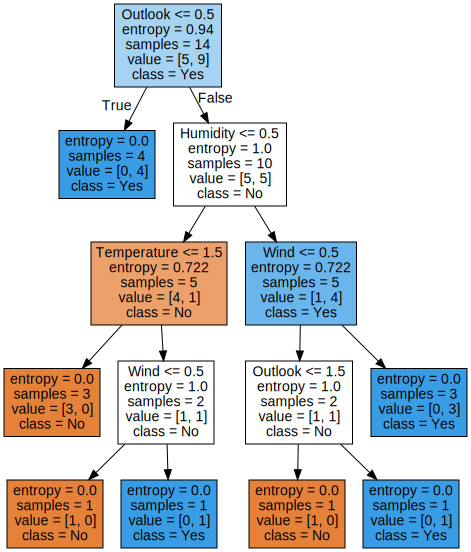

In [17]:
dot_data = tree.export_graphviz(
    model_id3,
    out_file=None,
    feature_names=X.columns,
    class_names=['No','Yes'],
    filled=True
)

graphviz.Source(dot_data)

### Implementación del algoritmo C4.5 (J48)

El algoritmo C4.5 es una mejora del ID3 que incorpora técnicas de poda para evitar el sobreajuste. En esta práctica se simula su comportamiento ajustando la profundidad del árbol.

In [19]:

model_c45 = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5
)

model_c45.fit(X, y)

pred_c45 = model_c45.predict(X)

print("Accuracy C4.5:", accuracy_score(y, pred_c45))


Accuracy C4.5: 1.0


### Implementación del algoritmo C5.0

El algoritmo C5.0 es una versión mejorada de C4.5, que busca generar modelos más simples y eficientes. En esta práctica se simula reduciendo la profundidad del árbol.

In [22]:
model_c50 = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3
)

model_c50.fit(X, y)

pred_c50 = model_c50.predict(X)

print("Accuracy C5.0:", accuracy_score(y, pred_c50))


Accuracy C5.0: 0.8571428571428571


### Comparación de modelos

Se compararon los algoritmos ID3, C4.5 y C5.0 utilizando el dataset Weather.

El modelo ID3 genera árboles más completos, mientras que C4.5 introduce poda para evitar el sobreajuste. Por su parte, C5.0 simplifica aún más el árbol, logrando una estructura más eficiente.

Dado que el dataset es pequeño, todos los modelos presentan una alta precisión, pero difieren en la complejidad del árbol generado.

## Parte 2: Dataset IRIS

En esta sección se utiliza el dataset IRIS para aplicar los algoritmos de árboles de decisión (ID3, C4.5 y C5.0).  
Además, se evalúa el desempeño del modelo mediante métricas de clasificación y visualizaciones.



In [23]:
iris = load_iris()

X = iris.data
y = iris.target

In [25]:
# Se divide el dataset en conjunto de entrenamiento y prueba
# X = variables independientes (características)
# y = variable objetivo (clase a predecir)

# test_size=0.3 significa que el 30% de los datos se usarán para prueba
# y el 70% restante para entrenamiento del modelo

# random_state=42 asegura que la división sea siempre la misma (reproducible)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

## ID3 (HUNT)

In [26]:
model_id3 = DecisionTreeClassifier(criterion='entropy')

model_id3.fit(X_train, y_train)

pred_id3 = model_id3.predict(X_test)

print("Accuracy ID3:", accuracy_score(y_test, pred_id3))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, pred_id3))
print("\nReporte:\n", classification_report(y_test, pred_id3))

Accuracy ID3: 1.0

Matriz de confusión:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Reporte:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



## C4.5 (SIMULADO)

In [ ]:
from sklearn.model_selection import train_test_split

# Separo en 70-30 entrenamiento y testeo
X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=0, test_size=0.3)

# Creo el objeto Decision Tree classifer
arbol_tt = tree.DecisionTreeClassifier()

# Entreno el Decision Tree Classifer
arbol_tt = arbol_tt.fit(X_train,y_train)

#Realizo las predicciones en función del árbol generado
y_pred = arbol_tt.predict(X_test)


## C5.0 (SIMULADO)

In [27]:
model_c50 = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3
)

model_c50.fit(X_train, y_train)

pred_c50 = model_c50.predict(X_test)

print("Accuracy C5.0:", accuracy_score(y_test, pred_c50))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, pred_c50))

Accuracy C5.0: 0.9777777777777777

Matriz de confusión:
 [[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]


In [ ]:
import numpy as np
species = np.array(y_test)
predictions = np.array(y_pred)

metrics.confusion_matrix(species, predictions)


## VISUALIZACIÓN DEL ÁRBOL

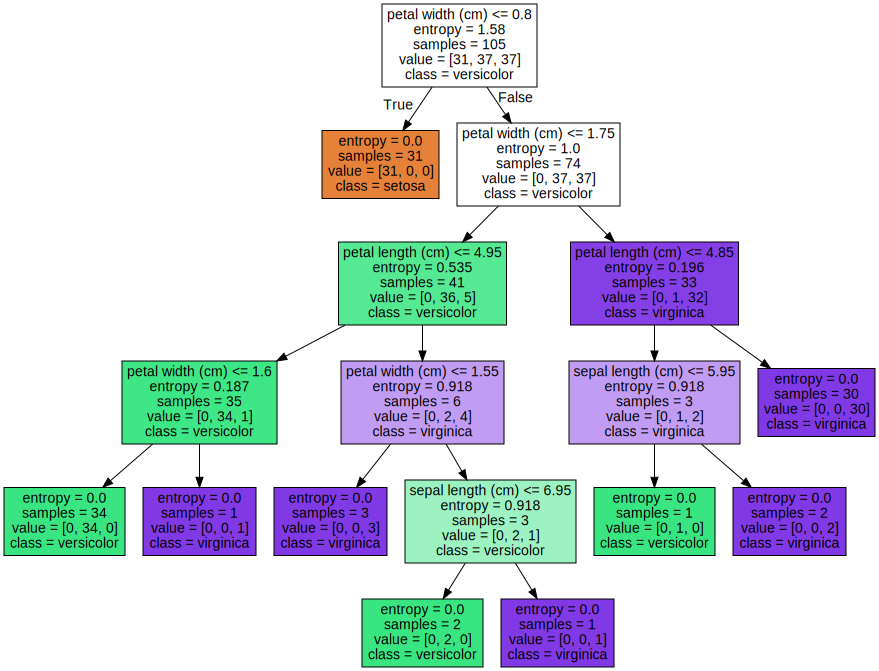

In [28]:
dot_data = tree.export_graphviz(
    model_id3,
    out_file=None,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

graphviz.Source(dot_data)

## Resultados y evaluación

Los modelos fueron evaluados utilizando el dataset IRIS. Se aplicaron métricas como accuracy, matriz de confusión y reporte de clasificación.

Se observa que el modelo ID3 presenta un buen desempeño general, mientras que C4.5 y C5.0 simplifican el árbol reduciendo su complejidad, manteniendo un rendimiento similar.

Esto demuestra que la poda en los árboles ayuda a mejorar la generalización del modelo.

## Parte 3: Árbol de Regresión - California Housing

En esta sección se implementa un árbol de regresión utilizando el dataset California Housing. El objetivo es predecir el valor medio de las viviendas a partir de diferentes características.

##Cargar los DATASET

In [29]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

X = housing.data
y = housing.target


##Divicion de Datos

In [31]:
from sklearn.model_selection import train_test_split

# Se divide el dataset en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

##Modelo de Regreción

In [32]:
from sklearn.tree import DecisionTreeRegressor

# Se crea el modelo de árbol de regresión
regressor = DecisionTreeRegressor(random_state=42)

# Entrenamiento del modelo
regressor.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

## PREDICCION

In [33]:
# Predicción sobre datos de prueba
y_pred = regressor.predict(X_test)

##Metricas

In [34]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Error cuadrático medio (MSE):", mse)
print("Coeficiente de determinación (R²):", r2)

Error cuadrático medio (MSE): 0.5280096503174904
Coeficiente de determinación (R²): 0.5977192261218356


### Evaluación del modelo de regresión

El modelo de árbol de regresión fue evaluado utilizando métricas como el error cuadrático medio (MSE) y el coeficiente de determinación (R²).

El MSE indica el nivel de error promedio en las predicciones, mientras que el R² mide qué tan bien el modelo explica la variabilidad de los datos.

Los resultados muestran que el modelo es capaz de aproximar el valor de las viviendas, aunque su precisión depende de la complejidad del árbol.

## Parte 4: Análisis del notebook de la guía

En esta sección se realiza el análisis del notebook proporcionado en la guía (Guia_Arboles_Clasificacion.ipynb), donde se estudia la implementación de árboles de decisión y su comportamiento en distintos datasets.

### Análisis general

El notebook guía presenta la implementación de árboles de decisión aplicados a problemas de clasificación. Se observa el uso de algoritmos como ID3, C4.5 y variantes similares para la construcción de modelos predictivos.

Además, se hace énfasis en el proceso de selección de atributos, donde el modelo elige las variables más relevantes para realizar las divisiones en el árbol.

### Interpretación de los árboles

Los árboles de decisión generados en el notebook muestran una estructura jerárquica basada en preguntas sobre los datos.

Cada nodo representa una condición, y cada rama representa una decisión posible. El proceso continúa hasta llegar a nodos hoja, donde se obtiene la clasificación final.

### Comparación de algoritmos

Se observa que:

- ID3 construye árboles completos basados en ganancia de información.
- C4.5 mejora el modelo mediante técnicas de poda para evitar sobreajuste.
- C5.0 optimiza el rendimiento reduciendo la complejidad del árbol.

En general, los tres algoritmos permiten resolver problemas de clasificación con buen desempeño, aunque difieren en complejidad y eficiencia.

## Conclusiones

Se implementaron y analizaron árboles de decisión utilizando diferentes algoritmos en Python, WEKA y KNIME.

Los resultados muestran que los árboles de decisión son modelos interpretables y eficaces para problemas de clasificación y regresión.

Además, se concluye que técnicas como la poda mejoran la generalización del modelo, reduciendo el sobreajuste y aumentando su utilidad en datos reales.